In [17]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [18]:
# Load the data
data = pd.read_csv("/content/heart.csv")

In [19]:
view_data = pd.read_csv("/content/heart.csv")
view_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [20]:
# Set the axis
Y = data["target"]
X = data.drop("target", axis=1)

In [21]:
# Import the StandardScaler to scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


(1025, 13)

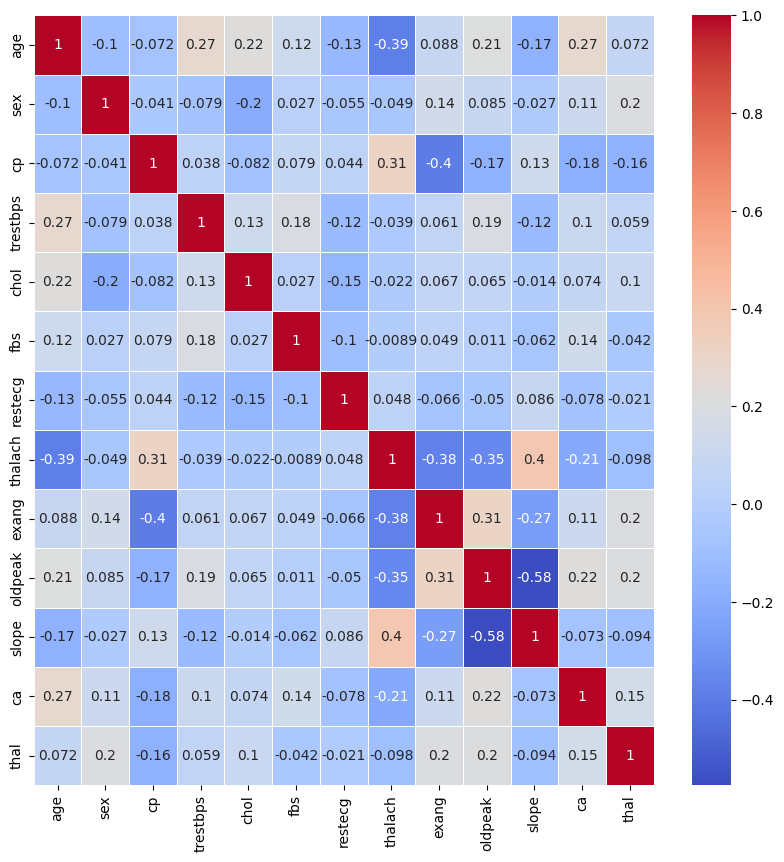

In [22]:
# Check the correlation
corr_matrix = X.corr()
plt.figure(figsize = (10,10))
sns.heatmap(corr_matrix, annot = True , cmap = "coolwarm", linewidth = 0.5)
X.shape

In [23]:
# Import test_train_split
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [24]:
# Import the sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [25]:
# Set parameters for model1 with Dropout
model1 = Sequential([
    Dense(32, activation = "relu", input_shape = (13,)),
    Dense(16, activation = "relu"),
    Dropout(0.2),
    Dense(16, activation = "relu"),
    Dropout(0.1),
    Dense(2, activation = "softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Model 2 without Dropout
model2 = Sequential([
    Dense(32, activation = "relu", input_shape = (13,)),
    Dense(16, activation = "relu"),
    Dense(16, activation = "relu"),
    Dense(2, activation = "softmax")
])

In [13]:
# Compile the model1
model1.compile(optimizer = 'adam',
               loss = 'sparse_categorical_crossentropy',
               metrics = ['accuracy'])
model1.summary()
history1 = model1.fit(train_x, train_y,
                      epochs = 130,
                      batch_size = 100,
                      validation_data = (test_x,test_y))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4463 - loss: 0.9125 - val_accuracy: 0.4146 - val_loss: 0.8045
Epoch 2/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5405 - loss: 0.7403 - val_accuracy: 0.5073 - val_loss: 0.7124
Epoch 3/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6019 - loss: 0.6692 - val_accuracy: 0.6098 - val_loss: 0.6501
Epoch 4/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6732 - loss: 0.6289 - val_accuracy: 0.6927 - val_loss: 0.6038
Epoch 5/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7573 - loss: 0.5746 - val_accuracy: 0.7366 - val_loss: 0.5645
Epoch 6/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7639 - loss: 0.5352 - val_accuracy: 0.7707 - val_loss: 0.5273
Epoch 7/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7868 - loss: 0.5027 - val_accuracy: 0.7805 - val_loss: 0.4945
Epoch 8/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8114 - loss: 0.4644 - val_accuracy: 0.7707 - val_loss: 0.4663

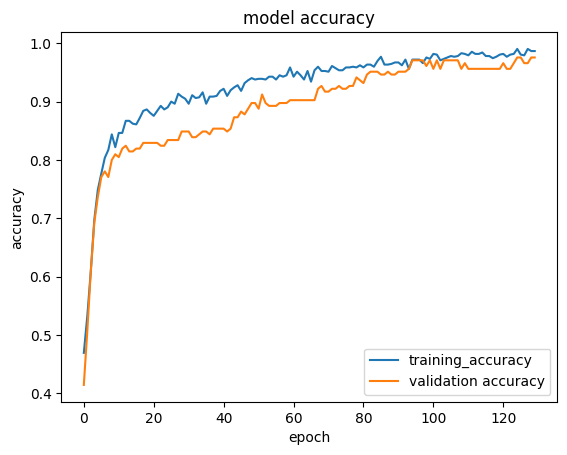

In [14]:
# Plot
plt.plot(history1.history['accuracy'], label = 'training_accuracy')
plt.plot(history1.history['val_accuracy'], label = 'validation accuracy')
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc = 'lower right')
plt.show()

In [15]:
model2.compile(optimizer = 'adam',
               loss = 'sparse_categorical_crossentropy',
               metrics = ['accuracy'])
model2.summary()
history2 = model2.fit(train_x, train_y,
                      epochs = 130,
                      batch_size = 100,
                      validation_data = (test_x,test_y))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6763 - loss: 0.6454 - val_accuracy: 0.7415 - val_loss: 0.5882
Epoch 2/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7285 - loss: 0.5846 - val_accuracy: 0.7902 - val_loss: 0.5466
Epoch 3/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8075 - loss: 0.5281 - val_accuracy: 0.8195 - val_loss: 0.5062
Epoch 4/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8242 - loss: 0.4818 - val_accuracy: 0.8146 - val_loss: 0.4725
Epoch 5/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8518 - loss: 0.4328 - val_accuracy: 0.8195 - val_loss: 0.4467
Epoch 6/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8314 - loss: 0.4166 - val_accuracy: 0.8146 - val_loss: 0.4295
Epoch 7/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8467 - loss: 0.3754 - val_accuracy: 0.8195 - val_loss: 0.4161
Epoch 8/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8552 - loss: 0.3568 - val_accuracy: 0.8195 - val_loss: 0.4061

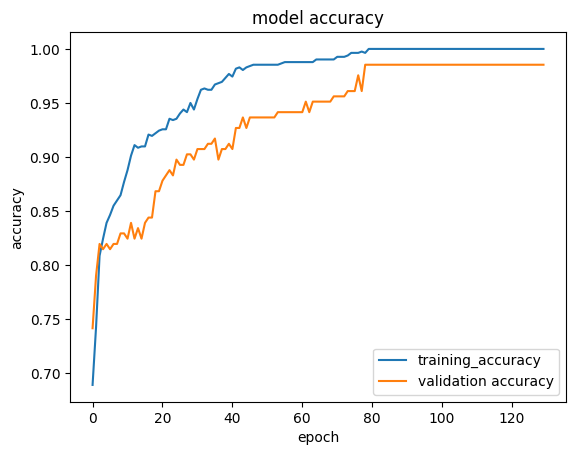

In [16]:
plt.plot(history2.history['accuracy'], label = 'training_accuracy')
plt.plot(history2.history['val_accuracy'], label = 'validation accuracy')
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc = 'lower right')
plt.show()